# Run all

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler

# Plotting defaults for consistency and accessibility
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.prop_cycle'] = cycler('color', plt.cm.tab10.colors)

from src.single_variable.bisection import bisection
from src.single_variable.secant import secant
from src.single_variable.newton import newton
from src.single_variable.damped_newton import damped_newton
from src.single_variable.brent import brent


In [3]:
def f(x):
    return np.cos(x) - x


def df(x):
    return -np.sin(x) - 1

result_newton = newton(f, df, x0=1.5)

In [4]:
methods = {
    "Bisection": bisection(f, 0.0, 1.0),
    "Secant": secant(f, 0.0, 1.0),
    "Newton": newton(f, df, 0.5),
    "Damped Newton": damped_newton(f, df, 0.5),
    "Brent": brent(f, 0.0, 1.0),
}

summary = []

for name, result in methods.items():
    summary.append({
        "Method": name,
        "Root": result["root"],
        "Converged": result["converged"],
        "Iterations": result["iterations"],
        "Final Error": result["final_error"],
        "Final Residual": result["final_residual"],
        "Message": result["message"],
    })

df_summary = pd.DataFrame(summary)
df_summary

,Method,Root,Converged,Iterations,Final Error,Final Residual,Message
0,Bisection,0.739085,True,24,5.960464e-08,7.747025e-09,converged by residual tolerance
1,Secant,0.739085,True,5,2.108754e-08,2.667866e-13,converged by residual tolerance
2,Newton,0.739085,True,3,5.653223e-05,1.180978e-09,converged by residual tolerance
3,Damped Newton,0.739085,True,11,1.373717e-08,5.747675e-09,converged by residual tolerance
4,Brent,0.739085,True,5,2.964360e-06,6.109329e-09,converged by residual tolerance


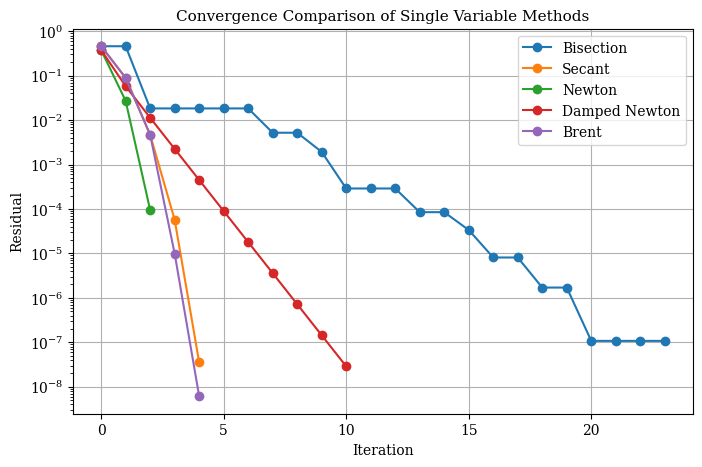

In [5]:
plt.figure(figsize=(8, 5))

for name, result in methods.items():
    residuals = []

    for step in result["history"]:

        if "fx" in step:
            residuals.append(abs(step["fx"]))

        elif "f_curr" in step:
            residuals.append(abs(step["f_curr"]))

        elif "fb" in step:
            residuals.append(abs(step["fb"]))

        elif "norm_f" in step:
            residuals.append(abs(step["norm_f"]))

    if len(residuals) > 0:
        plt.semilogy(
            range(len(residuals)),
            residuals,
            marker="o",
            label=name
        )

plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.title("Convergence Comparison of Single Variable Methods")

plt.legend()
plt.grid(True)

plt.savefig(
    "../latex/figures/single_variable_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()